In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rfm = pd.read_csv("../data/rfm_churn.csv")
rfm.head()

Matplotlib is building the font cache; this may take a moment.


,customer_unique_id,recency,frequency,monetary,churned
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,0
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,1
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,1


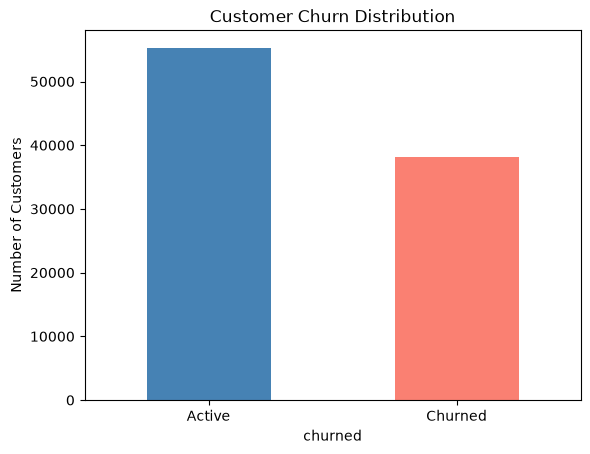

In [2]:
churn_counts = rfm["churned"].value_counts()
churn_counts.plot(kind="bar", color=["steelblue", "salmon"])
plt.xticks([0, 1], ["Active", "Churned"], rotation=0)
plt.title("Customer Churn Distribution")
plt.ylabel("Number of Customers")
plt.show()

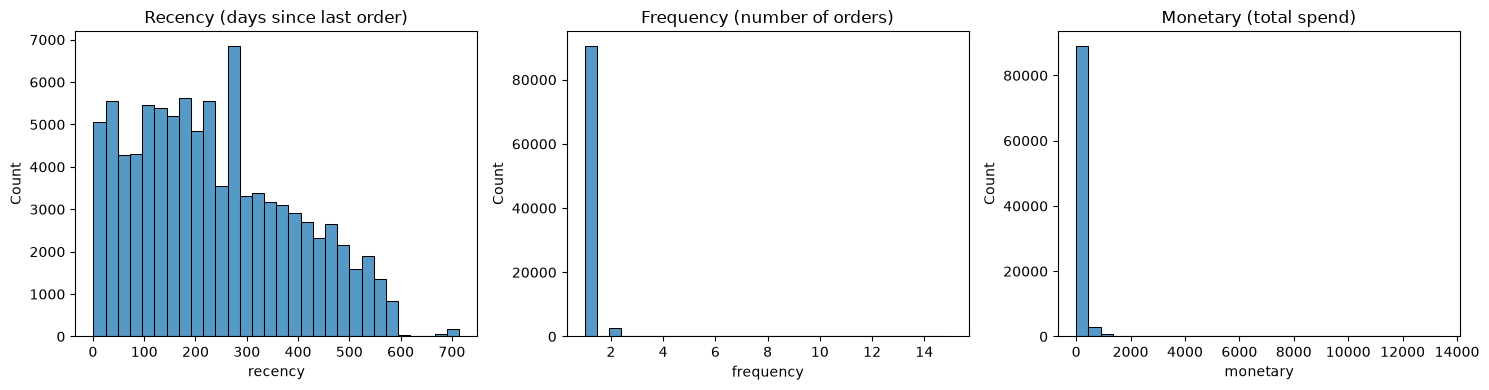

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm["recency"], bins=30, ax=axes[0])
axes[0].set_title("Recency (days since last order)")

sns.histplot(rfm["frequency"], bins=30, ax=axes[1])
axes[1].set_title("Frequency (number of orders)")

sns.histplot(rfm["monetary"], bins=30, ax=axes[2])
axes[2].set_title("Monetary (total spend)")

plt.tight_layout()
plt.savefig("../dashboard/eda_rfm.png", dpi=150)
plt.show()

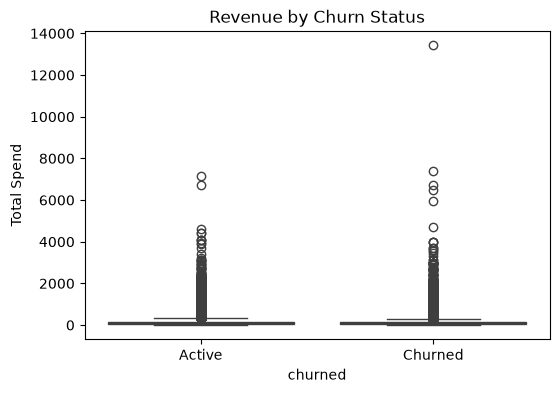

In [4]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=rfm, x="churned", y="monetary")
plt.xticks([0, 1], ["Active", "Churned"])
plt.title("Revenue by Churn Status")
plt.ylabel("Total Spend")
plt.savefig("../dashboard/churn_vs_revenue.png", dpi=150)
plt.show()

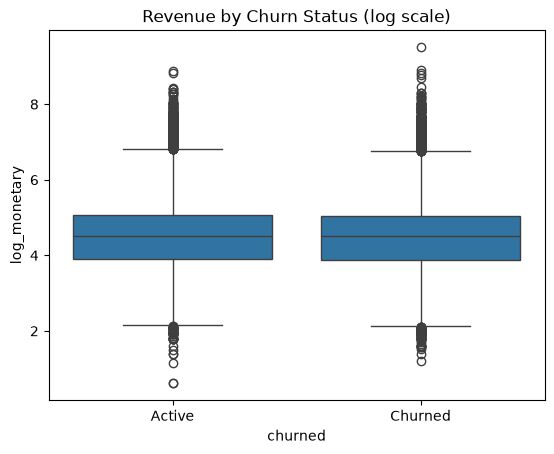

In [5]:
import numpy as np
rfm["log_monetary"] = np.log1p(rfm["monetary"])
sns.boxplot(data=rfm, x="churned", y="log_monetary")
plt.xticks([0, 1], ["Active", "Churned"])
plt.title("Revenue by Churn Status (log scale)")
plt.show()

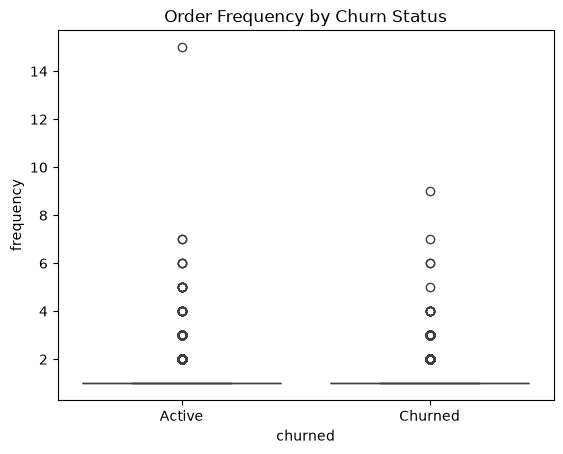

In [6]:
sns.boxplot(data=rfm, x="churned", y="frequency")
plt.xticks([0, 1], ["Active", "Churned"])
plt.title("Order Frequency by Churn Status")
plt.show()

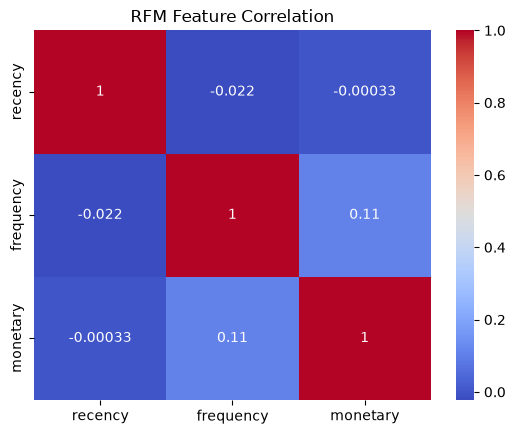

In [7]:
corr = rfm[["recency", "frequency", "monetary"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("RFM Feature Correlation")
plt.savefig("../dashboard/rfm_correlation.png", dpi=150)
plt.show()

## EDA Findings
- Most customers made only 1 order — frequency distribution is heavily right-skewed
  (typical for e-commerce, most customers are one-time buyers)
- Churned customers show [higher/lower/similar] average spend compared to active customers
- Recency and churn are directly related by definition, but frequency/monetary show
  [describe pattern] — early signal that frequency alone might be a decent churn predictor